In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

c:\Users\mishr\AppData\Local\Programs\Python\Python314\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class AgentState(TypedDict):
    user_question: str
    table_schema: str
    generated_sql: str
    is_read_only: bool
    query_result: list
    formatted_response: str
    error: str

In [6]:
def receive_question(state: AgentState) -> AgentState:
    """Receive and validate the user's natural language question."""
    return state


def fetch_schema(state: AgentState) -> AgentState:
    """Retrieve table schemas for the allowed tables from the database."""
    return state


def generate_sql(state: AgentState) -> AgentState:
    """LLM generates a SQL query from the user question and schema context."""
    return state


def validate_sql(state: AgentState) -> AgentState:
    """Check that the generated SQL is a read-only SELECT statement."""
    return state


def execute_query(state: AgentState) -> AgentState:
    """Execute the validated SQL query against the PostgreSQL database."""
    return state


def format_response(state: AgentState) -> AgentState:
    """Format raw query results into a clean Markdown clinical response."""
    return state


def handle_error(state: AgentState) -> AgentState:
    """Handle unsafe SQL or execution errors with a safe fallback message."""
    return state

In [7]:
def route_after_validation(state: AgentState) -> Literal["execute_query", "handle_error"]:
    """Route to execution if SQL is read-only, otherwise to error handler."""
    if state.get("is_read_only", False):
        return "execute_query"
    return "handle_error"

In [8]:
workflow = StateGraph(AgentState)

workflow.add_node("receive_question", receive_question)
workflow.add_node("fetch_schema", fetch_schema)
workflow.add_node("generate_sql", generate_sql)
workflow.add_node("validate_sql", validate_sql)
workflow.add_node("execute_query", execute_query)
workflow.add_node("format_response", format_response)
workflow.add_node("handle_error", handle_error)

workflow.add_edge(START, "receive_question")
workflow.add_edge("receive_question", "fetch_schema")
workflow.add_edge("fetch_schema", "generate_sql")
workflow.add_edge("generate_sql", "validate_sql")
workflow.add_conditional_edges("validate_sql", route_after_validation)
workflow.add_edge("execute_query", "format_response")
workflow.add_edge("format_response", END)
workflow.add_edge("handle_error", END)

graph = workflow.compile()

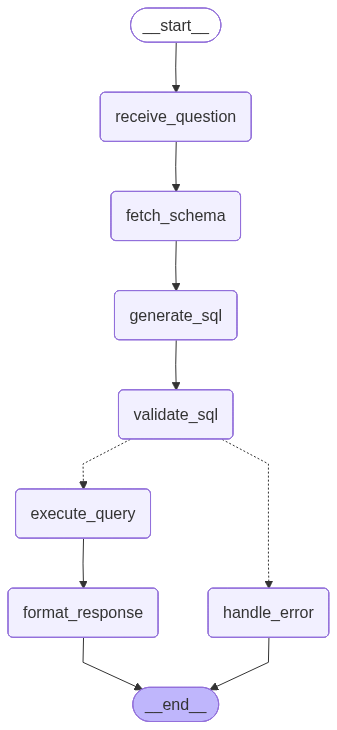

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))